<a href="https://colab.research.google.com/github/cmpe255-group9/chicago-crime-detection/blob/main/notebooks/check_in_2_chicago_crime_eda_year_balanced_sample.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CMPE 255 - Group 9 Project  
## Check-in 2: Exploratory Data Analysis

This notebook is part of the CMPE 255 Group 9 machine learning project. The dataset used in this project is the Chicago Crimes dataset from the City of Chicago Data Portal. It contains reported crime records from 2001 to the present, including information such as crime type, date, location, arrest status, domestic status, district, community area, and geographic coordinates.

The main goal of the overall project is to predict whether a crime record results in an arrest. In Check-in 1, we performed an initial EDA using the latest 50,000 records from the dataset. For Check-in 2, we use a year-balanced sample to better examine long-term patterns across different years.

In this notebook, we focus only on exploratory data analysis. We examine arrest trends over time, crime volume patterns, domestic versus non-domestic incidents, location-based arrest rates, crime type and time interactions, and arrest rate differences by day and hour. These analyses help us better understand the structure of the dataset before moving into machine learning modeling in later stages.

In [49]:
import os

# Create a folder for exported figures
FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

In [24]:
import pandas as pd
import requests
import time

# Socrata API endpoint for the Chicago Crimes dataset
BASE_URL = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"

# Create a year-balanced sample: 2,000 records from each year
YEARS = list(range(2001, 2026 + 1))
ROWS_PER_YEAR = 2000   # 26 years x 2000 = 52,000 rows

# Select only the columns needed for EDA and future modeling
selected_cols = [
    "id", "case_number", "date", "block", "iucr", "primary_type",
    "description", "location_description", "arrest", "domestic",
    "beat", "district", "ward", "community_area", "fbi_code",
    "x_coordinate", "y_coordinate", "year", "latitude", "longitude",
    "location", "updated_on"
]

# Store yearly samples before combining them
all_parts = []

for y in YEARS:
    # Query 2,000 records for each year
    params = {
        "$select": ",".join(selected_cols),
        "$where": f"year = {y}",
        "$limit": ROWS_PER_YEAR,
        "$order": "date DESC"
    }

    # Send request to the API
    r = requests.get(BASE_URL, params=params)
    r.raise_for_status()

    # Convert the API response into a DataFrame
    part = pd.DataFrame(r.json())

    # Keep track of which year the sample came from
    part["sample_year"] = y

    # Append the yearly sample to the list
    all_parts.append(part)

    print(f"{y}: {len(part)} rows")

    # Add a short pause to avoid sending too many requests too quickly
    time.sleep(0.2)

# Combine all yearly samples into one DataFrame
df = pd.concat(all_parts, ignore_index=True)

# Display the final shape and first few rows
print(df.shape)
df.head()

2001: 2000 rows
2002: 2000 rows
2003: 2000 rows
2004: 2000 rows
2005: 2000 rows
2006: 2000 rows
2007: 2000 rows
2008: 2000 rows
2009: 2000 rows
2010: 2000 rows
2011: 2000 rows
2012: 2000 rows
2013: 2000 rows
2014: 2000 rows
2015: 2000 rows
2016: 2000 rows
2017: 2000 rows
2018: 2000 rows
2019: 2000 rows
2020: 2000 rows
2021: 2000 rows
2022: 2000 rows
2023: 2000 rows
2024: 2000 rows
2025: 2000 rows
2026: 2000 rows
(52000, 23)


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,x_coordinate,y_coordinate,year,latitude,longitude,location,updated_on,ward,community_area,sample_year
0,1917210,HH100082,2001-12-31T23:58:00.000,0000X N OGDEN AV,0810,THEFT,OVER $500,STREET,False,False,...,1166017,1900248,2001,41.88186382,-87.665846779,"{'latitude': '41.88186382', 'longitude': '-87....",2015-08-17T15:03:40.000,NaN,NaN,2001
1,1917250,HH100172,2001-12-31T23:55:00.000,043XX S PULASKI RD,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,1150352,1875802,2001,41.815100864,-87.724005581,"{'latitude': '41.815100864', 'longitude': '-87...",2015-08-17T15:03:40.000,NaN,NaN,2001
2,1919150,HH100019,2001-12-31T23:55:00.000,047XX S HALSTED ST,1310,CRIMINAL DAMAGE,TO PROPERTY,STREET,True,False,...,1171721,1873672,2001,41.808813388,-87.645683302,"{'latitude': '41.808813388', 'longitude': '-87...",2015-08-17T15:03:40.000,NaN,NaN,2001
3,1918303,HH100166,2001-12-31T23:55:00.000,032XX W FULLERTON AV,041A,BATTERY,AGGRAVATED: HANDGUN,STREET,False,False,...,1154518,1915816,2001,41.924821484,-87.707654064,"{'latitude': '41.924821484', 'longitude': '-87...",2015-08-17T15:03:40.000,NaN,NaN,2001
4,1918312,HH100067,2001-12-31T23:55:00.000,022XX S LEAVITT ST,0420,BATTERY,AGGRAVATED:KNIFE/CUTTING INSTR,STREET,False,False,...,1162083,1889354,2001,41.852052718,-87.680596503,"{'latitude': '41.852052718', 'longitude': '-87...",2015-08-17T15:03:40.000,NaN,NaN,2001


In Check-in 1, we collected the latest 50,000 records from the dataset by ordering the data by descending date. While this approach was useful for a quick initial exploration, it only represented the most recent crime records and did not capture the full time span of the dataset.

In this check-in, we used a different sampling strategy. Instead of taking only the most recent records overall, we retrieved 2,000 records from each year between 2001 and 2026. This created a year-balanced sample with 52,000 rows. The goal of this approach is to make sure that every year is represented equally in the exploratory analysis.

This sampling method is especially useful for comparing crime patterns, arrest rates, and temporal trends across years. Since the project goal is to predict whether a crime record results in an arrest, it is important to understand whether the relationship between features and the arrest outcome changes over time.

However, this sample is still not fully random. Within each year, the records are ordered by `date DESC`, meaning that we are taking the latest 2,000 records from each year. Therefore, this approach improves the time coverage compared to Check-in 1, but it may still include some within-year recency bias.

The output shows that 2,000 records were successfully collected for each year, resulting in a final dataset shape of `(52000, 23)`. The preview confirms that key variables such as crime type, arrest status, domestic flag, location, year, latitude, and longitude were successfully loaded.

In [25]:
import numpy as np

# Standardize column names for easier analysis
df.columns = df.columns.str.lower().str.replace(" ", "_")

# Convert date columns to datetime format
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["updated_on"] = pd.to_datetime(df["updated_on"], errors="coerce")

# Convert arrest values into a binary variable for rate calculations
df["arrest_binary"] = df["arrest"].astype(str).str.lower().map({
    "true": 1, "false": 0, "1": 1, "0": 0
})

# Convert domestic values into a binary variable for comparison
df["domestic_binary"] = df["domestic"].astype(str).str.lower().map({
    "true": 1, "false": 0, "1": 1, "0": 0
})

# Convert selected columns to numeric format for summaries and plots
num_cols = [
    "beat", "district", "ward", "community_area",
    "x_coordinate", "y_coordinate", "year", "latitude", "longitude"
]

for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Extract time-based variables from the crime date
df["hour"] = df["date"].dt.hour
df["day_of_week"] = df["date"].dt.day_name()
df["month"] = df["date"].dt.month
df["quarter"] = df["date"].dt.quarter
df["is_weekend"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)

# Create a season variable from the month
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Fall"
    return np.nan

df["season"] = df["month"].apply(get_season)

# Display the updated shape and selected EDA variables
print(df.shape)
df[["date", "year", "hour", "day_of_week", "month", "season", "arrest_binary"]].head()

(52000, 31)


,date,year,hour,day_of_week,month,season,arrest_binary
0,2001-12-31 23:58:00,2001,23,Monday,12,Winter,0
1,2001-12-31 23:55:00,2001,23,Monday,12,Winter,0
2,2001-12-31 23:55:00,2001,23,Monday,12,Winter,1
3,2001-12-31 23:55:00,2001,23,Monday,12,Winter,0
4,2001-12-31 23:55:00,2001,23,Monday,12,Winter,0


This cell prepares the dataset for exploratory data analysis. First, the column names are standardized by converting them to lowercase and replacing spaces with underscores. This makes the dataset easier to work with in later EDA steps.

The `date` and `updated_on` columns are converted into datetime format so that we can analyze crimes by time-related patterns. From the `date` column, several new variables are created, including `hour`, `day_of_week`, `month`, `quarter`, `is_weekend`, and `season`. These features help us explore whether crime records and arrest rates vary across different times of the day, days of the week, months, or seasons.

The `arrest` column is converted into a binary variable called `arrest_binary`, where `1` means the crime record resulted in an arrest and `0` means it did not. This makes it easier to calculate arrest rates in later EDA. Similarly, `domestic` is converted into `domestic_binary` so that domestic and non-domestic incidents can be compared more easily.

The output shows that the dataset now has 52,000 rows and 31 columns. The number of columns increased because new time-based and binary variables were added. The preview confirms that the date conversion and feature creation worked correctly. For example, the first records are from December 31, 2001, late at night, and they are correctly labeled as Monday and Winter.

## Repeating Check-in 1 EDA on the Year-Balanced Sample

In Check-in 1, the EDA was performed on the latest 50,000 crime records. In this check-in, we repeat several of the same basic EDA steps using a year-balanced sample with 2,000 records from each year. The purpose is to compare how the sampling strategy affects the observed crime distributions, arrest rates, temporal patterns, and geographic patterns.

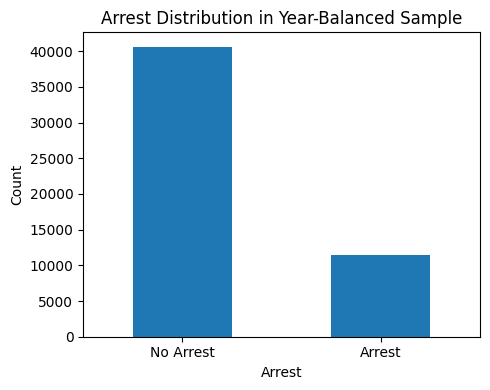

,count,percentage
arrest_binary,,
0,40618,78.11
1,11382,21.89


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count arrest and non-arrest records
arrest_counts = df["arrest_binary"].value_counts().sort_index()

# Plot arrest distribution
fig, ax = plt.subplots(figsize=(5, 4))
arrest_counts.plot(kind="bar", ax=ax)

ax.set_title("Arrest Distribution in Year-Balanced Sample")
ax.set_xlabel("Arrest")
ax.set_ylabel("Count")
ax.set_xticklabels(["No Arrest", "Arrest"], rotation=0)

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/arrest_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# Display counts and percentages
arrest_summary = pd.DataFrame({
    "count": arrest_counts,
    "percentage": (arrest_counts / len(df) * 100).round(2)
})

arrest_summary

This chart repeats the arrest distribution analysis from Check-in 1, but uses the new year-balanced sample instead of the latest 50,000 records. The purpose of repeating this plot is to check whether the overall balance between arrest and non-arrest records changes when the sample includes records from every year.

In Check-in 1, the dataset mainly represented the most recent crime records because the data was ordered by descending date. In this check-in, each year from 2001 to 2026 contributes 2,000 records. Therefore, the arrest distribution shown here reflects a broader historical sample rather than only recent crime activity.

This comparison is important because the arrest variable is the main outcome of interest in the project. If the arrest rate is noticeably different between the two samples, it suggests that the sampling strategy affects the target distribution. That would also mean that conclusions based only on the latest 50,000 records may not fully represent the long-term dataset.

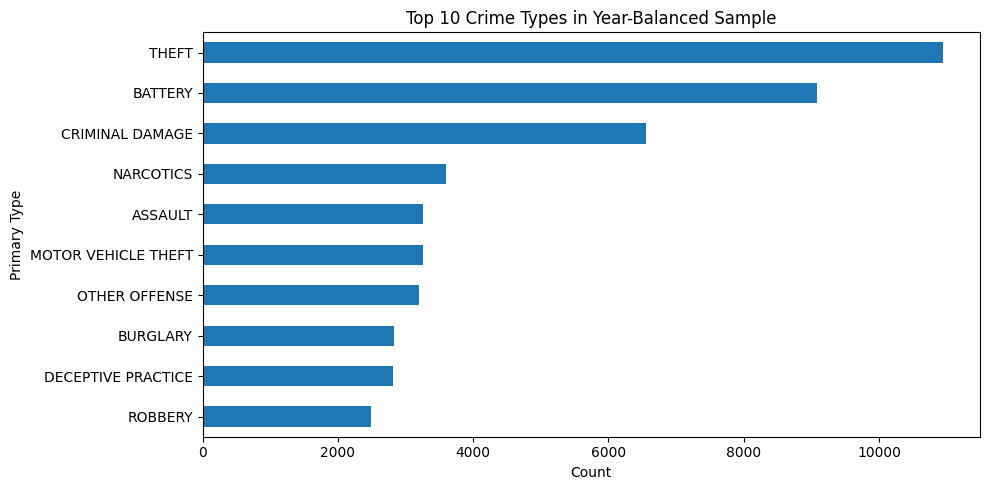

,count
primary_type,
THEFT,10945
BATTERY,9082
CRIMINAL DAMAGE,6549
NARCOTICS,3602
ASSAULT,3260
MOTOR VEHICLE THEFT,3259
OTHER OFFENSE,3195
BURGLARY,2828
DECEPTIVE PRACTICE,2814


In [51]:
# Count the most frequent crime types in the year-balanced sample
top_crimes = df["primary_type"].value_counts().head(10)

# Plot top 10 crime types
fig, ax = plt.subplots(figsize=(10, 5))
top_crimes.plot(kind="barh", ax=ax)

ax.set_title("Top 10 Crime Types in Year-Balanced Sample")
ax.set_xlabel("Count")
ax.set_ylabel("Primary Type")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/top_10_crime_types.png", dpi=300, bbox_inches="tight")
plt.show()

top_crimes

This plot repeats the top crime type analysis from Check-in 1 using the year-balanced sample. The goal is to compare whether the most common crime categories remain similar when the sample includes records from all years rather than only the most recent records.

Because crime patterns can change over time, the top crime types in the latest 50,000 records may not match the top crime types across a broader historical sample. For example, some crime categories may have become more or less common in recent years due to policy changes, reporting changes, or social trends.

This comparison helps us understand whether the dataset from Check-in 1 was mainly describing recent crime patterns, while the new sample provides a more balanced view across the full time period. If the ranking of crime types changes, this would suggest that time coverage has a meaningful impact on the EDA results.

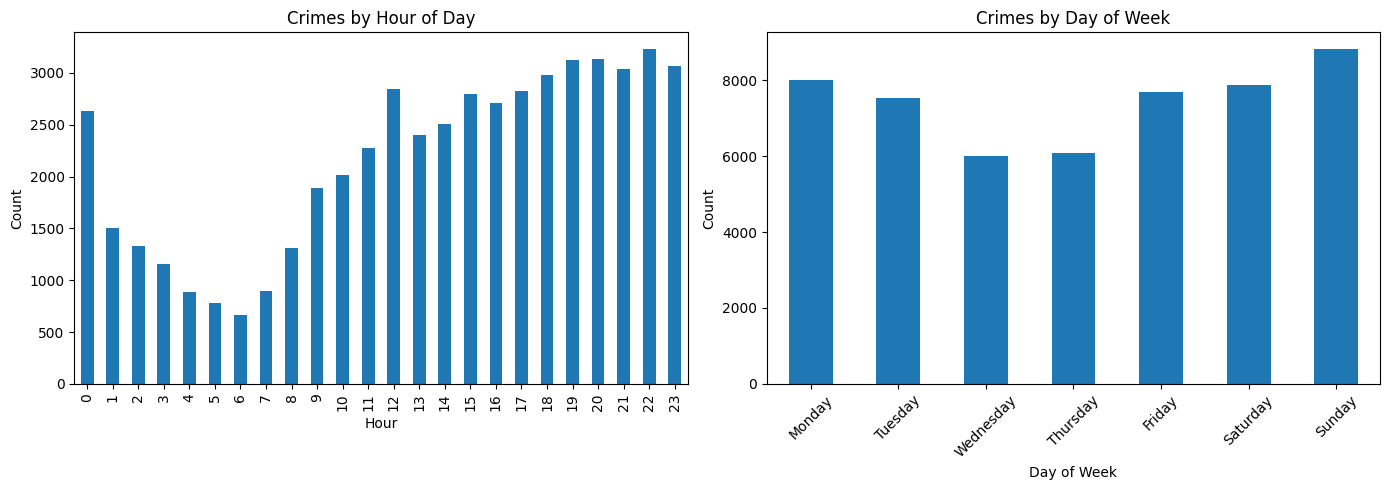

In [52]:
# Define weekday order for consistent plotting
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot crime counts by hour of day
df["hour"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Crimes by Hour of Day")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Count")

# Plot crime counts by day of week
df["day_of_week"].value_counts().reindex(day_order).plot(kind="bar", ax=axes[1])
axes[1].set_title("Crimes by Day of Week")
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/crimes_by_hour_and_day.png", dpi=300, bbox_inches="tight")
plt.show()

This cell repeats the time-based crime volume analysis from Check-in 1. It shows how crime records are distributed by hour of day and day of week in the year-balanced sample.

The comparison is useful because the Check-in 1 sample only included the most recent records, while this sample includes records from every year. If the hourly or weekly patterns look similar across both samples, it suggests that these time-based crime patterns are relatively stable. If they look different, it may indicate that recent crime timing patterns do not fully represent the historical dataset.

These plots are also useful because time features may be related to arrest patterns. For example, crime volume may peak at certain hours, but those hours may not necessarily have the highest arrest rate. This motivates later EDA comparing arrest rates by time variables, not just crime counts.

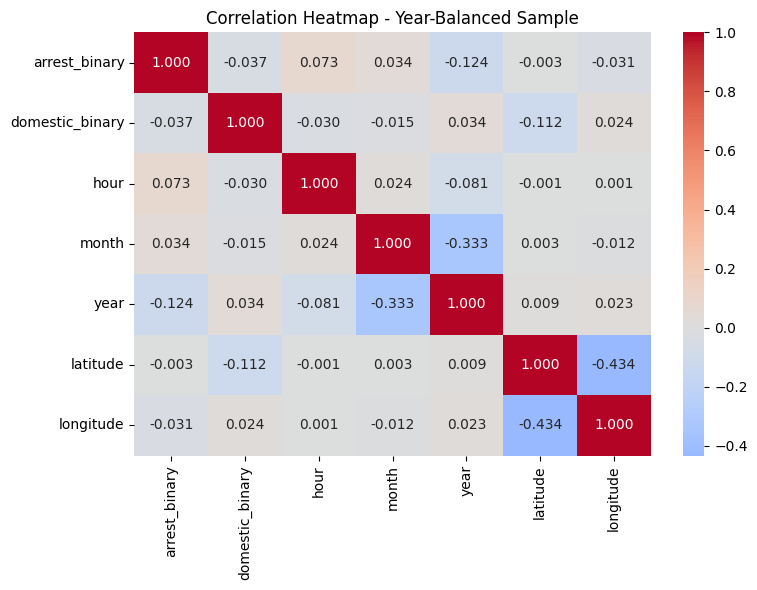

In [53]:
# Select numeric variables for a simple correlation analysis
numeric_cols = [
    "arrest_binary",
    "domestic_binary",
    "hour",
    "month",
    "year",
    "latitude",
    "longitude"
]

# Keep only columns that exist in the dataframe
numeric_cols = [col for col in numeric_cols if col in df.columns]

# Compute correlations
corr = df[numeric_cols].corr()

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax)

ax.set_title("Correlation Heatmap - Year-Balanced Sample")

plt.tight_layout()
plt.savefig(f"{FIGURE_DIR}/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

This heatmap repeats the basic correlation analysis from Check-in 1 using the year-balanced sample. It shows linear relationships among selected numeric variables, including the binary arrest variable and time/location-related variables.

The purpose of repeating this analysis is to check whether the relationships observed in the recent-only sample are still visible when records from all years are included. Since this sample has equal representation from each year, it may reveal different relationships involving year, time, and location.

This correlation plot should be interpreted carefully because many important variables in this dataset are categorical, such as crime type, description, district, and location description. Therefore, this heatmap is only a basic numeric summary and does not capture the full relationship between the features and arrest outcome.

## EDA on the Year-Balanced Sample

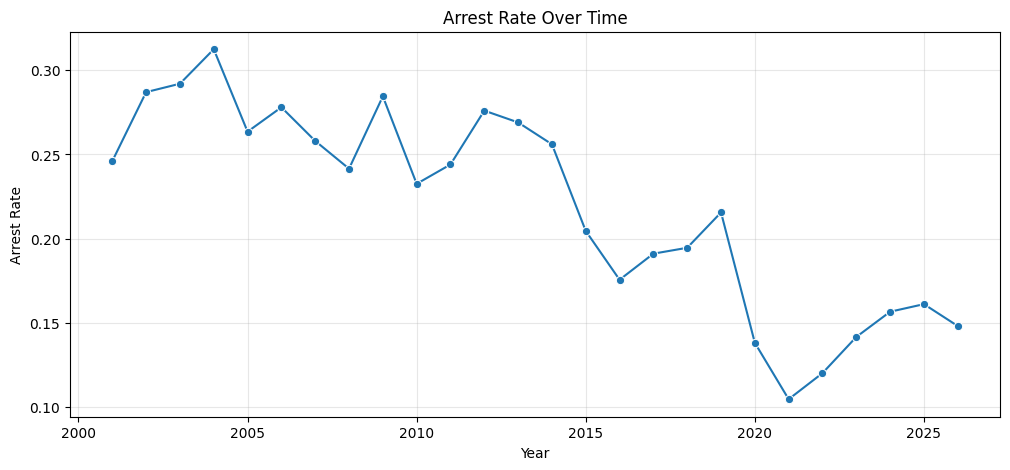

,year,arrest_rate,n
21,2022,0.1200,2000
22,2023,0.1415,2000
23,2024,0.1565,2000
24,2025,0.1610,2000
25,2026,0.1480,2000


In [54]:
# Calculate yearly arrest rate and number of records per year
yearly = (
    df.groupby("year")["arrest_binary"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "arrest_rate", "count": "n"})
    .reset_index()
    .sort_values("year")
)

# Plot arrest rate trend over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x="year", y="arrest_rate", marker="o")

# Add chart labels and grid
plt.title("Arrest Rate Over Time")
plt.xlabel("Year")
plt.ylabel("Arrest Rate")
plt.grid(True, alpha=0.3)
plt.savefig(f"{FIGURE_DIR}/arrest_rate_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

# Display the most recent years in the summary table
yearly.tail()

This chart shows how the arrest rate changes over time in the year-balanced sample. Since we selected 2,000 records from each year, each year has the same sample size in this analysis. This makes the yearly arrest rates easier to compare directly.

The plot shows that arrest rates were generally higher in the early 2000s, mostly around 25% to 30%. After the mid-2010s, the arrest rate begins to decline more clearly. The lowest point appears around 2021, where the arrest rate is close to 10%. After that, the rate increases slightly between 2022 and 2025, but it remains lower than the levels observed in the early years.

This is an important pattern because it suggests that arrest outcomes are not stable over time. In Check-in 1, we only used the latest 50,000 records, so this long-term trend was not visible. By using a year-balanced sample, we can see that the relationship between crime records and arrest outcomes may have changed across years.

The table below the chart shows the most recent years in the sample. Each year has exactly 2,000 records, confirming that the sample is balanced by year. The recent arrest rates are around 12% to 16%, which is much lower than many of the earlier years shown in the line chart.

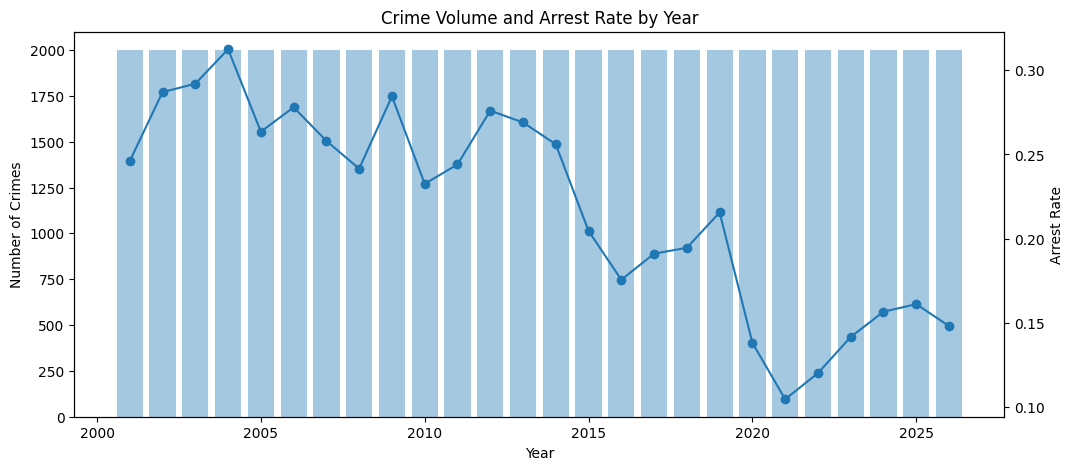

In [55]:
# Create a figure with one main axis
fig, ax1 = plt.subplots(figsize=(12, 5))

# Plot the number of crime records for each year
ax1.bar(yearly["year"], yearly["n"], alpha=0.4)
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of Crimes")

# Create a second y-axis for arrest rate
ax2 = ax1.twinx()

# Plot yearly arrest rate on the second axis
ax2.plot(yearly["year"], yearly["arrest_rate"], marker="o")
ax2.set_ylabel("Arrest Rate")

# Add chart title
plt.title("Crime Volume and Arrest Rate by Year")
plt.savefig(f"{FIGURE_DIR}/crime_volume_arrest_rate_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

This plot shows crime volume and arrest rate together by year. The bar chart confirms that the yearly sample sizes are consistent, while the line chart shows how the arrest rate changes over time.

The arrest rate is generally higher in the early 2000s and lower in recent years, especially after 2020. Compared with Check-in 1, this view provides a clearer long-term trend instead of focusing only on recent records.

Since the crime volume is fixed by the sampling design, the main takeaway from this plot is the change in arrest rate across years.

,domestic_binary,arrest_rate,n,domestic_label
0,0,0.226420,41953,Non-domestic
1,1,0.187419,10047,Domestic


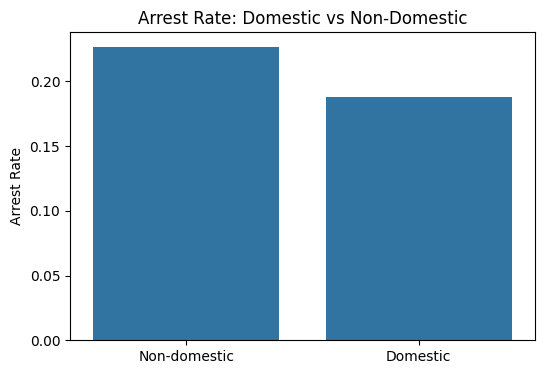

In [56]:
# Calculate arrest rate and record count by domestic status
domestic_eda = (
    df.groupby("domestic_binary")["arrest_binary"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "arrest_rate", "count": "n"})
    .reset_index()
)

# Create readable labels for the domestic status
domestic_eda["domestic_label"] = domestic_eda["domestic_binary"].map({
    0: "Non-domestic",
    1: "Domestic"
})

# Display summary table
display(domestic_eda)

# Plot arrest rate for domestic and non-domestic records
plt.figure(figsize=(6, 4))
sns.barplot(data=domestic_eda, x="domestic_label", y="arrest_rate")

# Add chart labels
plt.title("Arrest Rate: Domestic vs Non-Domestic")
plt.xlabel("")
plt.ylabel("Arrest Rate")
plt.savefig(f"{FIGURE_DIR}/domestic_vs_non_domestic_arrest_rate.png", dpi=300, bbox_inches="tight")

plt.show()

This analysis compares arrest rates for domestic and non-domestic crime records. Non-domestic incidents have an arrest rate of about 22.6%, while domestic incidents have a lower arrest rate of about 18.7%.

The table also shows that non-domestic records make up most of the sample. This means the overall arrest rate is more strongly influenced by non-domestic crimes.

This result suggests that domestic status is related to arrest outcomes and should be considered when interpreting arrest patterns in the dataset.

,location_description,arrest_rate,n
61,DEPARTMENT STORE,0.508102,864
54,CTA PLATFORM,0.490196,204
73,GROCERY FOOD STORE,0.466570,688
126,SIDEWALK,0.461870,3711
63,DRUG STORE,0.439394,264
15,ALLEY,0.335915,1033
70,GAS STATION,0.300000,600
32,CHA APARTMENT,0.299213,254
141,VEHICLE NON-COMMERCIAL,0.287559,852
113,RESIDENCE PORCH/HALLWAY,0.258165,643


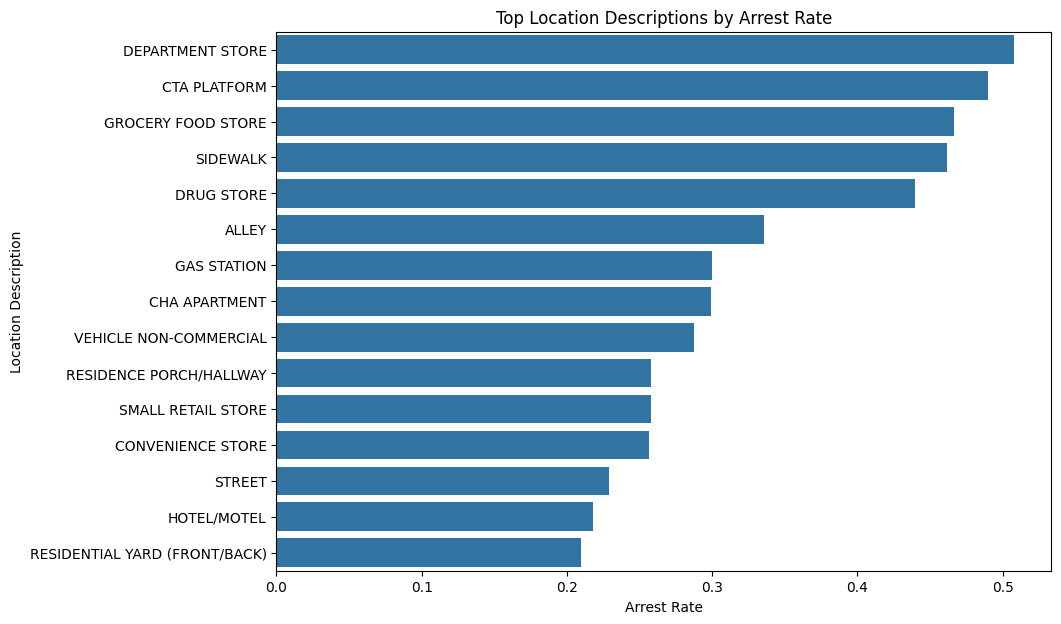

In [57]:
# Calculate arrest rate and record count for each location description
loc_eda = (
    df.groupby("location_description")["arrest_binary"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "arrest_rate", "count": "n"})
    .reset_index()
)

# Keep only location categories with enough records for a more stable comparison
loc_eda_filtered = loc_eda[loc_eda["n"] >= 200].sort_values("arrest_rate", ascending=False)

# Display the top location descriptions by arrest rate
display(loc_eda_filtered.head(20))

# Plot the top 15 location descriptions by arrest rate
plt.figure(figsize=(10, 7))
sns.barplot(
    data=loc_eda_filtered.head(15),
    y="location_description",
    x="arrest_rate"
)

# Add chart labels
plt.title("Top Location Descriptions by Arrest Rate")
plt.xlabel("Arrest Rate")
plt.ylabel("Location Description")
plt.savefig(f"{FIGURE_DIR}/top_location_descriptions_by_arrest_rate.png", dpi=300, bbox_inches="tight")

plt.show()

This analysis compares arrest rates across different crime location descriptions. To avoid unstable results from very small categories, only locations with at least 200 records are included.

The highest arrest rates appear in locations such as department stores, CTA platforms, grocery food stores, sidewalks, and drug stores. These locations may be associated with crime types where arrests are more likely, such as theft, drug-related incidents, or incidents occurring in public/commercial areas.

This plot adds more detail than only looking at crime type because it shows that where an incident happens may also be related to the chance of an arrest.

,location_description,arrest_rate,n
114,RESIDENCE-GARAGE,0.051948,616
96,OTHER (SPECIFY),0.055794,233
46,COMMERCIAL / BUSINESS OFFICE,0.102128,470
102,PARKING LOT / GARAGE (NON RESIDENTIAL),0.114458,498
109,RESIDENCE,0.117949,8953
57,CTA TRAIN,0.119048,252
116,RESTAURANT,0.142857,1099
17,APARTMENT,0.148412,7998
23,BANK,0.167488,203
95,OTHER,0.172322,1503


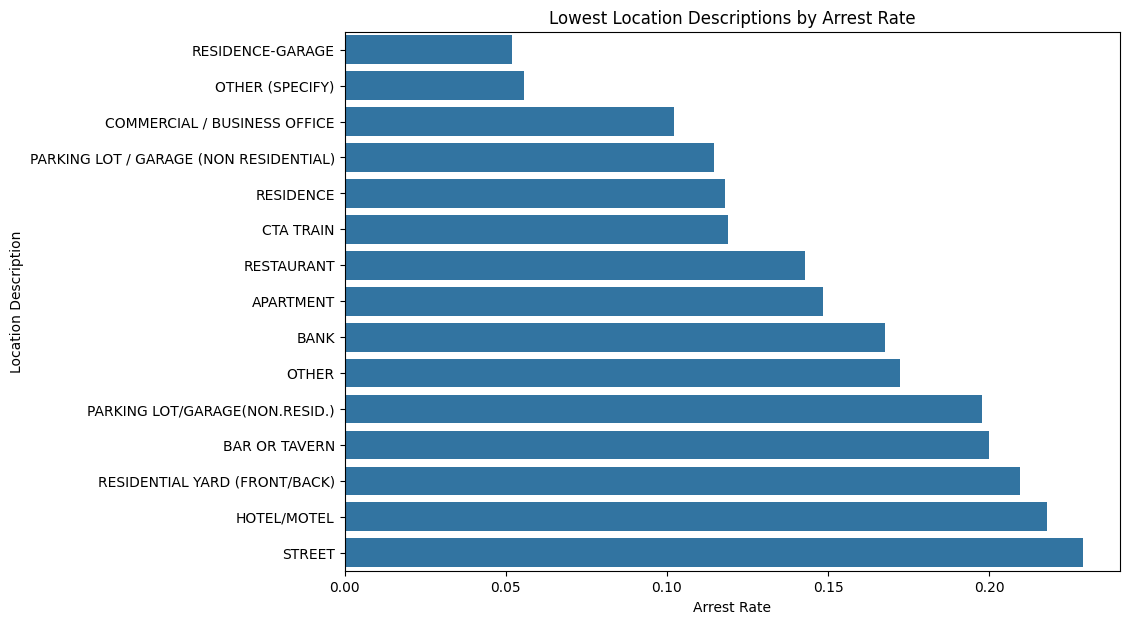

In [58]:
# Display the location descriptions with the lowest arrest rates
display(loc_eda_filtered.sort_values("arrest_rate").head(20))

# Plot the bottom 15 location descriptions by arrest rate
plt.figure(figsize=(10, 7))
sns.barplot(
    data=loc_eda_filtered.sort_values("arrest_rate").head(15),
    y="location_description",
    x="arrest_rate"
)

# Add chart labels
plt.title("Lowest Location Descriptions by Arrest Rate")
plt.xlabel("Arrest Rate")
plt.ylabel("Location Description")
plt.savefig(f"{FIGURE_DIR}/lowest_location_descriptions_by_arrest_rate.png", dpi=300, bbox_inches="tight")

plt.show()

This plot shows the location descriptions with the lowest arrest rates. Locations such as residence-garage, commercial/business office, parking lots, residences, and CTA trains appear near the bottom.

These lower arrest rates may be related to the types of crimes that commonly occur in these locations. For example, residential or parking-related incidents may include property crimes where an arrest is less likely at the time of reporting.

Together with the previous plot, this analysis shows that location type is associated with different arrest outcomes. Some public or commercial places have much higher arrest rates, while residential or private locations tend to have lower arrest rates.

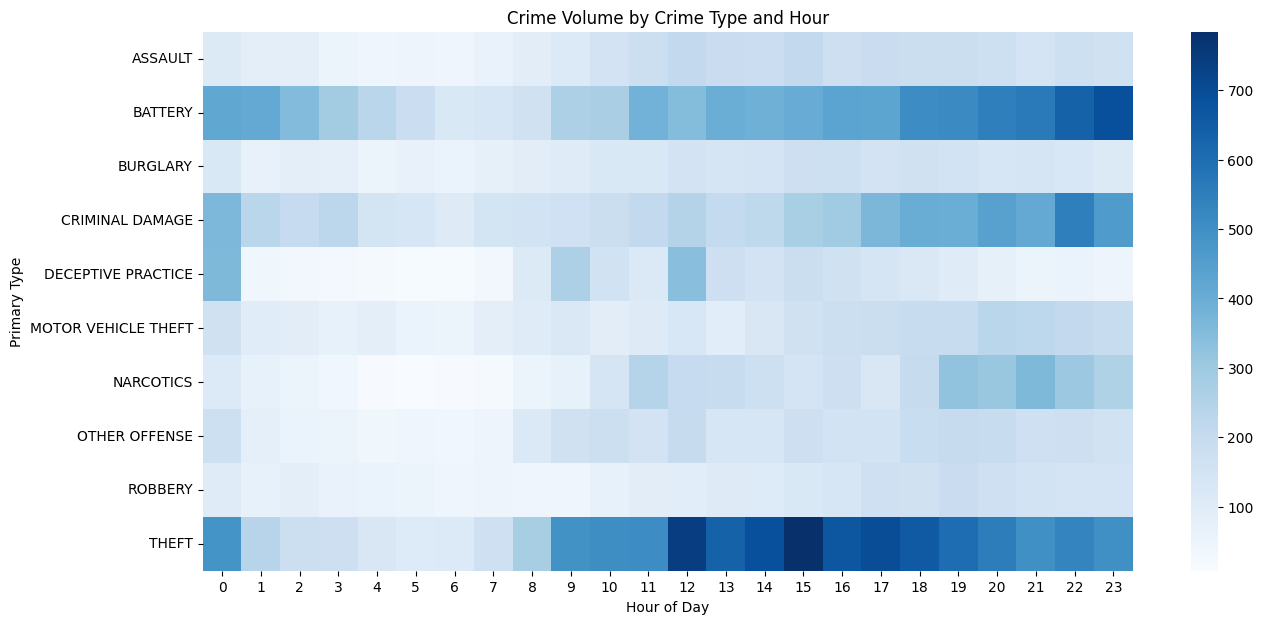

In [59]:
# Create a pivot table showing crime counts by crime type and hour
crime_hour_count = heat_df.pivot_table(
    index="primary_type",
    columns="hour",
    values="id",
    aggfunc="count"
).fillna(0)

# Plot the crime count heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(crime_hour_count, cmap="Blues", annot=False)

# Add chart labels
plt.title("Crime Volume by Crime Type and Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Primary Type")
plt.savefig(f"{FIGURE_DIR}/crime_volume_by_crime_type_and_hour.png", dpi=300, bbox_inches="tight")

plt.show()

This heatmap shows how crime volume changes by crime type and hour of day. Darker cells indicate higher numbers of records for that crime type during that hour.

Theft has the strongest concentration during daytime and afternoon hours, especially around midday to late afternoon. Battery and criminal damage appear more common in the evening and late-night hours. These patterns suggest that different crime types follow different time-of-day distributions.

This plot is useful because it shows that hour alone does not tell the full story. The relationship between time and crime volume depends strongly on the type of crime.

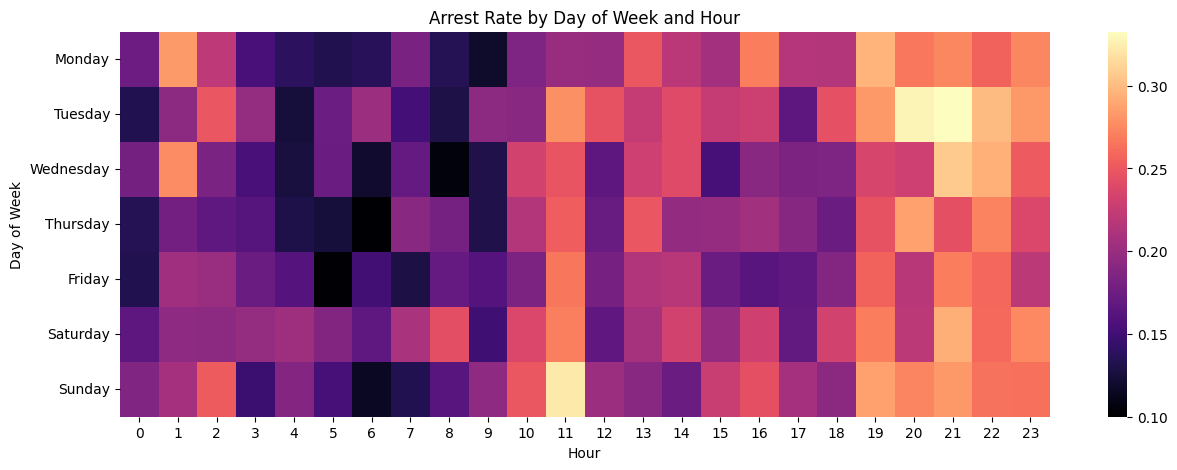

In [60]:
# Define weekday order for a more readable heatmap
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create a pivot table showing average arrest rate by day and hour
day_hour_arrest = df.pivot_table(
    index="day_of_week",
    columns="hour",
    values="arrest_binary",
    aggfunc="mean"
).reindex(day_order)

# Plot the arrest rate heatmap
plt.figure(figsize=(15, 5))
sns.heatmap(day_hour_arrest, cmap="magma", annot=False)

# Add chart labels
plt.title("Arrest Rate by Day of Week and Hour")
plt.xlabel("Hour")
plt.ylabel("Day of Week")
plt.savefig(f"{FIGURE_DIR}/arrest_rate_by_day_and_hour.png", dpi=300, bbox_inches="tight")
plt.show()

This heatmap shows how arrest rates vary by both day of week and hour of day. Lighter cells represent higher arrest rates, while darker cells represent lower arrest rates.

The highest arrest rates appear more often during late morning, evening, and nighttime hours. Some of the lowest arrest rates appear during early morning hours, especially around 4 AM to 6 AM.

This plot shows that arrest patterns are not only related to the day or hour separately. The combination of day and hour gives a more detailed view of when arrests are more or less likely.

In [61]:
import os
import shutil
from google.colab import files

FIGURE_DIR = "figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

if os.path.exists("figures.zip"):
    os.remove("figures.zip")

shutil.make_archive("figures", "zip", FIGURE_DIR)
files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>